In [1]:
# Diabetes Risk Prediction (Logistic Regression)
# 1. Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [3]:
# 2. Load Dataset
df = pd.read_csv("diabetes_risk.csv")

df.head()

,Glucose,BMI,Age,Insulin,BloodPressure,Diabetes
0,177,39.475044,25,265.349395,81,1
1,158,28.351714,45,272.777924,95,1
2,82,35.617497,56,261.553229,63,1
3,141,30.747688,68,265.545308,105,0
4,172,38.797647,47,81.681037,74,1


In [4]:
# 3. Explore Dataset
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Glucose        100 non-null    int64  
 1   BMI            100 non-null    float64
 2   Age            100 non-null    int64  
 3   Insulin        100 non-null    float64
 4   BloodPressure  100 non-null    int64  
 5   Diabetes       100 non-null    int64  
dtypes: float64(2), int64(4)
memory usage: 4.8 KB


,Glucose,BMI,Age,Insulin,BloodPressure,Diabetes
count,100.000000,100.000000,100.000000,100.000000,100.00000,100.000000
mean,133.200000,28.804566,46.480000,158.567969,100.84000,0.500000
std,36.357095,6.374615,13.370766,75.849941,23.22256,0.502519
min,70.000000,18.208854,21.000000,30.313130,60.00000,0.000000
25%,102.750000,23.552103,36.750000,102.013228,79.00000,0.000000
50%,136.000000,28.644809,47.000000,145.779086,100.00000,0.500000
75%,165.500000,34.838374,57.000000,232.140561,123.00000,1.000000
max,198.000000,39.868346,69.000000,275.247405,139.00000,1.000000


In [5]:
# 4. Check Missing Values
df.isnull().sum()

Glucose          0
BMI              0
Age              0
Insulin          0
BloodPressure    0
Diabetes         0
dtype: int64

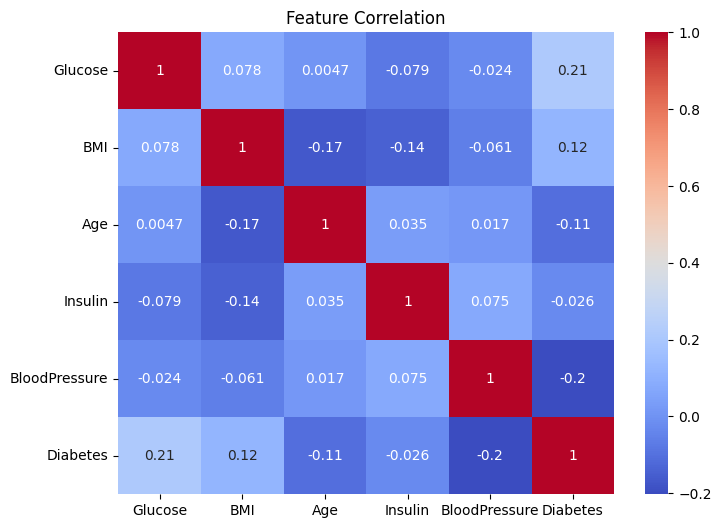

In [6]:
# 5. Data Visualization
# Correlation Heatmap
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Feature Correlation")
plt.show()

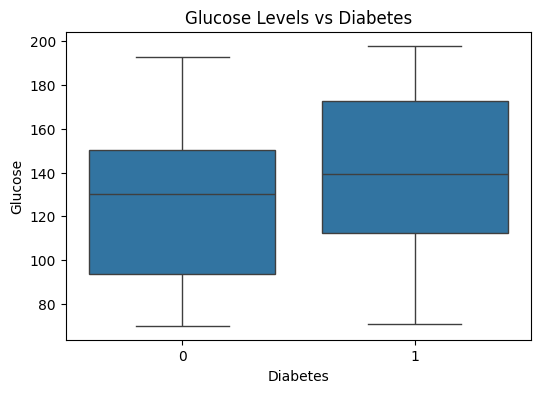

In [7]:
# Glucose vs Diabetes
plt.figure(figsize=(6,4))
sns.boxplot(x='Diabetes', y='Glucose', data=df)
plt.title("Glucose Levels vs Diabetes")
plt.show()

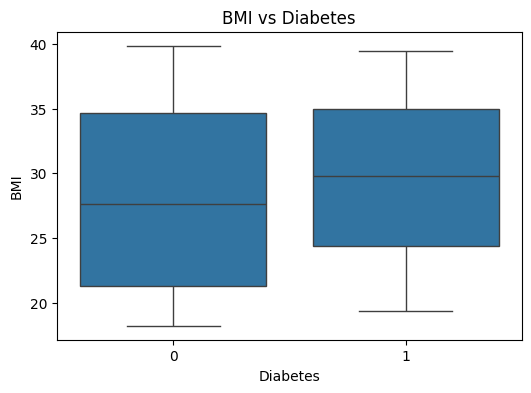

In [8]:
# BMI vs Diabetes
plt.figure(figsize=(6,4))
sns.boxplot(x='Diabetes', y='BMI', data=df)
plt.title("BMI vs Diabetes")
plt.show()

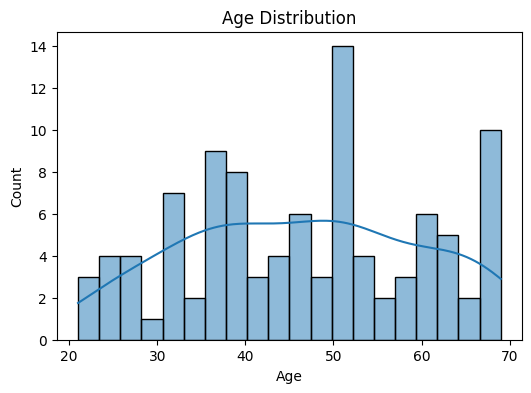

In [9]:
# Age Distribution
plt.figure(figsize=(6,4))
sns.histplot(df['Age'], bins=20, kde=True)
plt.title("Age Distribution")
plt.show()

In [12]:
# 6. Define Features and Target
X = df[['Glucose','BMI','Age','Insulin','BloodPressure']]
y = df['Diabetes']

In [13]:
# 7. Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [14]:
# 8. Train Logistic Regression Model
model = LogisticRegression()

model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [15]:
# 9. Make Predictions
y_pred = model.predict(X_test)

In [16]:
# 10. Evaluate Model
print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.6

Confusion Matrix:
[[5 5]
 [3 7]]

Classification Report:
              precision    recall  f1-score   support

           0       0.62      0.50      0.56        10
           1       0.58      0.70      0.64        10

    accuracy                           0.60        20
   macro avg       0.60      0.60      0.60        20
weighted avg       0.60      0.60      0.60        20



In [17]:
# 11. Predict Diabetes Risk for New Patient
new_patient = np.array([[130,28,45,120,80]])

prediction = model.predict(new_patient)

if prediction[0] == 1:
    print("Patient is at risk of Diabetes")
else:
    print("Patient is NOT at risk of Diabetes")

Patient is at risk of Diabetes


C:\Users\singh\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
